In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics 
from sklearn.metrics import classification_report
from xailib.data_loaders.dataframe_loader import prepare_dataframe

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [79]:
df = pd.read_csv("../../datasets/COVID_transformedData.csv")
class_field = 'Class_label'

In [80]:
df.head()

,id,Name,CountryName,X,Y,Start time,End time,Duration,Class_label,N merged events,...,NM_Duration,DM_Start,DM_End,DM_Duration,SH_Start,SH_End,SH_Duration,IM_Start,IM_End,IM_Duration
0,AF_almost no disease_12_17-02-2020_17-05-2020,AF_almost no disease_12_17-02-2020_17-05-2020,Afghanistan,69.183334,34.516666,17/2/2020,17/05/2020,91,almost no disease,12,...,0,0,0,0,0,0,0,0,0,0
1,AF_almost no disease_5_06-07-2020_16-08-2020,AF_almost no disease_5_06-07-2020_16-08-2020,Afghanistan,69.183334,34.516666,43989,16/08/2020,42,almost no disease,5,...,0,0,0,0,0,0,0,0,0,0
2,AF_almost no disease_35_14-09-2020_23-05-2021,AF_almost no disease_35_14-09-2020_23-05-2021,Afghanistan,69.183334,34.516666,14/09/2020,23/05/2021,252,almost no disease,35,...,2,0,0,0,0,0,0,0,0,0
3,AF_low to medium morbidity_5_17-05-2021_27-06-...,AF_low to medium morbidity_5_17-05-2021_27-06-...,Afghanistan,69.183334,34.516666,17/05/2021,27/06/2021,42,low to medium morbidity,5,...,6,0,0,0,0,0,0,0,0,0
4,AT_almost no disease_3_17-02-2020_15-03-2020,AT_almost no disease_3_17-02-2020_15-03-2020,Austria,16.366667,48.200000,17/02/2020,15/03/2020,28,almost no disease,3,...,0,0,0,0,0,0,0,0,0,0


In [58]:
list(df.columns)

['id',
 'Name',
 'CountryName',
 'X',
 'Y',
 'Start time',
 'End time',
 'Duration',
 'Class_label',
 'N merged events',
 'Temporal context start',
 'Temporal context end',
 'AND_6',
 'AND_5',
 'AND_4',
 'AND_3',
 'AND_2',
 'AND_1',
 'LMM_6',
 'LMM_5',
 'LMM_4',
 'LMM_3',
 'LMM_2',
 'LMM_1',
 'HM_6',
 'HM_5',
 'HM_4',
 'HM_3',
 'HM_2',
 'HM_1',
 'HMM_6',
 'HMM_5',
 'HMM_4',
 'HMM_3',
 'HMM_2',
 'HMM_1',
 'NM_6',
 'NM_5',
 'NM_4',
 'NM_3',
 'NM_2',
 'NM_1',
 'DM_6',
 'DM_5',
 'DM_4',
 'DM_3',
 'DM_2',
 'DM_1',
 'SH_6',
 'SH_5',
 'SH_4',
 'SH_3',
 'SH_2',
 'SH_1',
 'IM_6',
 'IM_5',
 'IM_4',
 'IM_3',
 'IM_2',
 'IM_1',
 'AND_Start',
 'AND_End',
 'AND_Duration',
 'LMM_Start',
 'LMM_End',
 'LMM_Duration',
 'HM_Start',
 'HM_End',
 'HM_Duration',
 'HMM_Start',
 'HMM_End',
 'HMM_Duration',
 'NM_Start',
 'NM_End',
 'NM_Duration',
 'DM_Start',
 'DM_End',
 'DM_Duration',
 'SH_Start',
 'SH_End',
 'SH_Duration',
 'IM_Start',
 'IM_End',
 'IM_Duration']

In [81]:
df=df[['AND_Start',
 'AND_End',
 'AND_Duration',
 'LMM_Start',
 'LMM_End',
 'LMM_Duration',
 'HM_Start',
 'HM_End',
 'HM_Duration',
 'HMM_Start',
 'HMM_End',
 'HMM_Duration',
 'NM_Start',
 'NM_End',
 'NM_Duration',
 'DM_Start',
 'DM_End',
 'DM_Duration',
 'SH_Start',
 'SH_End',
 'SH_Duration',
 'IM_Start',
 'IM_End',
 'IM_Duration','Class_label']]


In [60]:
df, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df, class_field)

In [61]:
#y = df["Class_label"].values
#X = df.loc[:,'AND_Start':'IM_Duration'].values

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33,random_state=12, stratify=y)
test_size = 0.3
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(df[feature_names], df[class_field],
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=df[class_field])


In [62]:
clf = RandomForestClassifier(n_estimators = 100)

In [63]:
clf.fit(X_train, y_train)

RandomForestClassifier()

In [64]:
y_pred = clf.predict(X_test)
target_names = clf.classes_

In [65]:
# metrics are used to find accuracy or error
print()
 
print("ACCURACY OF THE MODEL:", metrics.accuracy_score(y_test, y_pred))

#print(classification_report(y_test.values, y_pred.values, target_names=target_names))


ACCURACY OF THE MODEL: 0.7769784172661871


2024-03-08 14:41:50,733 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f88b88f27f0>


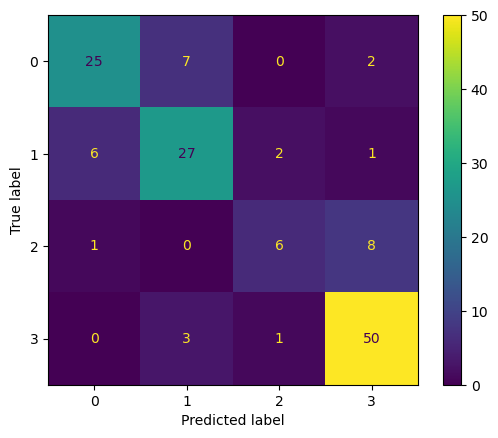

In [66]:
predictions = clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

### EXPLANATION WITH OLD LORE

In [67]:
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper

In [68]:
bbox = sklearn_classifier_wrapper(clf)

In [69]:
X_train.iloc[6].values

array([-3, -1,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0, -3, -1,  3,  0,  0,
        0,  0,  0,  0,  0,  0,  0])

In [70]:
inst = X_train.iloc[6].values
#X_train[6]
print('Instance ',inst)
print('True class ',y_train[6])
print('Predicted class ',clf.predict(inst.reshape(1, -1)))

Instance  [-3 -1  3  0  0  0  0  0  0  0  0  0 -3 -1  3  0  0  0  0  0  0  0  0  0]
True class  3
Predicted class  [3]


In [71]:
explainer = LoreTabularExplainer(bbox)
config = {'neigh_type':'geneticp', 'size':500, 'ocr':0.1, 'ngen':20}
explainer.fit(df, class_field, config)
exp = explainer.explain(inst)
print(exp)

In [72]:
exp.expDict

{'bb_pred': 3,
 'dt_pred': 3,
 'rule': {'premise': [{'att': 'LMM_Start',
    'op': '<=',
    'thr': 1.5,
    'is_continuous': True},
   {'att': 'LMM_Start', 'op': '>', 'thr': -0.5, 'is_continuous': True},
   {'att': 'LMM_Duration', 'op': '<=', 'thr': 0.5, 'is_continuous': True},
   {'att': 'DM_Start', 'op': '>', 'thr': -5.0, 'is_continuous': True},
   {'att': 'HMM_Duration', 'op': '<=', 'thr': 4.5, 'is_continuous': True},
   {'att': 'NM_End', 'op': '>', 'thr': -2.5, 'is_continuous': True},
   {'att': 'HMM_Start', 'op': '>', 'thr': -5.0, 'is_continuous': True}],
  'cons': 3,
  'class_name': 'Class_label'},
 'crules': [{'premise': [{'att': 'LMM_Start',
     'op': '<=',
     'thr': -0.5,
     'is_continuous': True},
    {'att': 'LMM_Start', 'op': '>', 'thr': -4.5, 'is_continuous': True},
    {'att': 'LMM_End', 'op': '<=', 'thr': -0.5, 'is_continuous': True},
    {'att': 'LMM_End', 'op': '>', 'thr': -1.5, 'is_continuous': True},
    {'att': 'NM_End', 'op': '>', 'thr': -4.0, 'is_continuous'

In [73]:
exp.plotRules()

### THE NEW LORE

In [74]:
from lore_sa.dataset import TabularDataset

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   AND_Start     461 non-null    int64 
 1   AND_End       461 non-null    int64 
 2   AND_Duration  461 non-null    int64 
 3   LMM_Start     461 non-null    int64 
 4   LMM_End       461 non-null    int64 
 5   LMM_Duration  461 non-null    int64 
 6   HM_Start      461 non-null    int64 
 7   HM_End        461 non-null    int64 
 8   HM_Duration   461 non-null    int64 
 9   HMM_Start     461 non-null    int64 
 10  HMM_End       461 non-null    int64 
 11  HMM_Duration  461 non-null    int64 
 12  NM_Start      461 non-null    int64 
 13  NM_End        461 non-null    int64 
 14  NM_Duration   461 non-null    int64 
 15  DM_Start      461 non-null    int64 
 16  DM_End        461 non-null    int64 
 17  DM_Duration   461 non-null    int64 
 18  SH_Start      461 non-null    int64 
 19  SH_End  

In [83]:
dataset = TabularDataset(df, class_name="Class_label")

In [99]:
dataset.df.info()
dataset.descriptor.keys()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   AND_Start     461 non-null    int64 
 1   AND_End       461 non-null    int64 
 2   AND_Duration  461 non-null    int64 
 3   LMM_Start     461 non-null    int64 
 4   LMM_End       461 non-null    int64 
 5   LMM_Duration  461 non-null    int64 
 6   HM_Start      461 non-null    int64 
 7   HM_End        461 non-null    int64 
 8   HM_Duration   461 non-null    int64 
 9   HMM_Start     461 non-null    int64 
 10  HMM_End       461 non-null    int64 
 11  HMM_Duration  461 non-null    int64 
 12  NM_Start      461 non-null    int64 
 13  NM_End        461 non-null    int64 
 14  NM_Duration   461 non-null    int64 
 15  DM_Start      461 non-null    int64 
 16  DM_End        461 non-null    int64 
 17  DM_Duration   461 non-null    int64 
 18  SH_Start      461 non-null    int64 
 19  SH_End  

dict_keys(['numeric', 'categorical', 'target'])

In [100]:
from lore_sa.encoder_decoder import TabularEnc
encoder = TabularEnc(dataset.descriptor)

encoded = []
for x in dataset.df.iloc:
    encoded.append(encoder.encode(x.values))

In [101]:
encoder.dataset_descriptor

{'numeric': {'AND_Start': {'index': 0,
   'min': -6,
   'max': 0,
   'mean': -1.665943600867679,
   'std': 2.5292013323223044,
   'median': 0.0,
   'q1': -4.0,
   'q3': 0.0},
  'AND_End': {'index': 1,
   'min': -6,
   'max': 0,
   'mean': -0.6572668112798264,
   'std': 1.330125979798622,
   'median': 0.0,
   'q1': -1.0,
   'q3': 0.0},
  'AND_Duration': {'index': 2,
   'min': 0,
   'max': 6,
   'mean': 1.3297180043383947,
   'std': 2.149763820870322,
   'median': 0.0,
   'q1': 0.0,
   'q3': 3.0},
  'LMM_Start': {'index': 3,
   'min': -6,
   'max': 0,
   'mean': -2.2668112798264644,
   'std': 2.7442359404606536,
   'median': 0.0,
   'q1': -6.0,
   'q3': 0.0},
  'LMM_End': {'index': 4,
   'min': -6,
   'max': 0,
   'mean': -0.8438177874186551,
   'std': 1.419395830361685,
   'median': 0.0,
   'q1': -1.0,
   'q3': 0.0},
  'LMM_Duration': {'index': 5,
   'min': 0,
   'max': 6,
   'mean': 1.841648590021692,
   'std': 2.389033071217937,
   'median': 0.0,
   'q1': 0.0,
   'q3': 4.0},
  'HM_Sta

In [102]:
print(encoded[1])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [103]:
encoder.decode(encoded[1])

ValueError: invalid literal for int() with base 10: 'almost no disease'

In [104]:
encoded_df = pd.DataFrame(encoded, columns = [encoder.encoded_features[i] for i in range(len(encoded[0]))])
encoded_df

,AND_Start,AND_End,AND_Duration,LMM_Start,LMM_End,LMM_Duration,HM_Start,HM_End,HM_Duration,HMM_Start,...,DM_Start,DM_End,DM_Duration,SH_Start,SH_End,SH_Duration,IM_Start,IM_End,IM_Duration,Class_label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-6,-5,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-6,-1,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,-4,-1,4,0,0,0,0,0,0,0,...,-1,-1,1,0,0,0,0,0,0,1
457,0,0,0,0,0,0,-6,-1,6,0,...,0,0,0,0,0,0,0,0,0,1
458,0,0,0,-6,-1,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
459,0,0,0,0,0,0,0,0,0,-6,...,-6,-6,1,0,0,0,0,0,0,2


In [105]:
from sklearn.metrics import f1_score, accuracy_score


feature_names = [c for c in encoded_df.columns if c != 'Class_label']
class_name = dataset.class_name
test_size= 0.3
random_state= 42

X_train, X_test, Y_train, Y_test = train_test_split(encoded_df[feature_names].values, encoded_df[class_name].values,
                                                    test_size=test_size,
                                                    random_state=random_state,
                                                    stratify=encoded_df[class_name].values)




# Train a random forest model

bb = RandomForestClassifier(n_estimators=100, random_state=random_state)

# bb = MLPClassifier(random_state=random_state)
bb.fit(X_train, Y_train)

Y_pred = bb.predict(X_test)
target_names = bb.classes_


print('Accuracy %.3f' % accuracy_score(Y_test, Y_pred))

# example of predictions
Y_pred = bb.predict(X_test)

from lore_sa.bbox import sklearn_classifier_bbox

bbox = sklearn_classifier_bbox.sklearnBBox(bb)

Accuracy 0.799


2024-03-08 14:47:52,126 matplotlib.colorbar DEBUG    locator: <matplotlib.ticker.AutoLocator object at 0x7f88b69263d0>


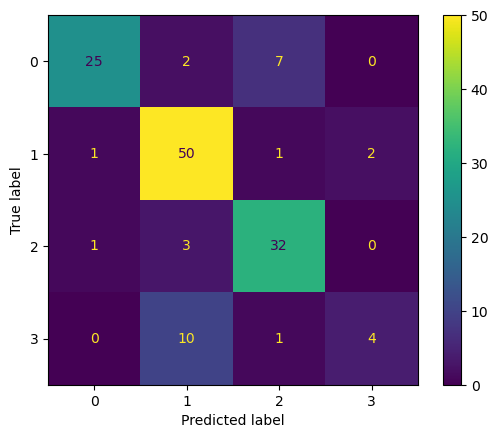

In [106]:
predictions = bb.predict(X_test)
cm = confusion_matrix(Y_test, predictions, labels=bb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bb.classes_)
disp.plot()
plt.show()

In [107]:
# random generation
features = [c for c in encoded_df.columns if c != dataset.class_name]

x = encoded_df[features].iloc[10].values

from lore_sa.neighgen.random import RandomGenerator

gen = RandomGenerator()

neighbour = gen.generate(x,10000, dataset.descriptor, onehotencoder = encoder)

neighbour.df

2024-03-08 14:47:54,026 root         WARNING  No target class is defined


,AND_Start,AND_End,AND_Duration,LMM_Start,LMM_End,LMM_Duration,HM_Start,HM_End,HM_Duration,HMM_Start,...,NM_Duration,DM_Start,DM_End,DM_Duration,SH_Start,SH_End,SH_Duration,IM_Start,IM_End,IM_Duration
0,-2.246292,-1.121093,4.757151,-4.577532,-0.044440,5.834964,-2.015182,-0.960489,5.160231,-4.119886,...,2.570481,-2.027705,-1.929579,0.002707,-0.076146,-0.747692,4.654170,-0.435165,-3.775262,3.607792
1,-2.528491,-5.270937,4.084699,-3.739688,-2.839428,4.791779,-0.601427,-5.715673,2.915629,-3.393658,...,0.269615,-4.179799,-1.049016,2.773252,-2.726298,-5.711856,1.578872,-5.915494,-5.431861,3.646532
2,-0.492281,-4.966143,0.483646,-4.212752,-4.545067,2.890431,-5.937374,-3.943352,1.861733,-0.019908,...,4.220586,-4.447478,-5.284289,1.319175,-4.404319,-1.217305,2.930442,-4.814072,-2.888984,0.990984
3,-1.579119,-4.219370,2.534928,-1.110255,-3.778969,2.824202,-2.798211,-4.756556,5.271481,-1.809349,...,0.119553,-0.569348,-5.823136,1.218854,-2.810625,-0.231859,2.309063,-3.424150,-2.021839,1.977489
4,-2.526317,-3.465723,4.168612,-5.758274,-0.659847,1.473100,-3.479899,-1.236094,2.857367,-5.495092,...,1.370871,-2.054091,-5.491407,3.139176,-2.378252,-2.191920,1.770086,-5.865722,-0.404291,2.277568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-1.696959,-5.859482,2.820960,-5.271735,-4.283533,5.072206,-4.146040,-5.488101,4.472445,-0.048215,...,1.603015,-3.143581,-0.860081,1.351247,-2.105076,-3.479876,4.813403,-3.033048,-2.612683,2.925072
9996,-0.819561,-0.092014,5.161227,-3.606289,-4.839870,4.931833,-1.371963,-4.952208,3.920816,-1.091825,...,4.492447,-3.412800,-0.855618,2.721176,-5.295767,-4.657106,2.434336,-1.434249,-1.389741,4.422020
9997,-0.708425,-1.472486,0.965673,-1.288727,-5.811969,0.904162,-1.411025,-2.313836,0.873700,-1.073804,...,4.998898,-4.191230,-0.759323,0.201020,-5.133046,-5.046987,2.798184,-0.688239,-1.933742,3.051591
9998,-2.208909,-2.632436,1.318443,-3.077887,-2.058840,1.153679,-4.306571,-4.847570,5.421659,-0.232118,...,0.951262,-1.654668,-5.588967,0.133441,-2.466442,-2.770417,5.509024,-2.349574,-4.869140,2.813921


In [108]:
neighbour.df['Class_label'] = bbox.predict(neighbour.df[features])
neighbour.set_class_name('Class_label')

#### Surrogate Model

In [109]:
from lore_sa.surrogate import DecisionTreeSurrogate

surrogate = DecisionTreeSurrogate()


surrogate.train(neighbour.df[features].values , neighbour.df['Class_label'] )

DecisionTreeClassifier()

In [110]:
x = encoded_df[features].iloc[10].values


rule = surrogate.get_rule(x, neighbour, encoder)

print (rule)

premises:
HM_End > -1.5004103183746338
LMM_End > -0.5041681528091431
AND_Start > -0.43262484669685364
LMM_Duration <= 3.4958592653274536
NM_Start > -5.537944078445435 
consequence: Class_label = low to medium morbidity


In [111]:
#counter rules
crules, deltas = surrogate.get_counterfactual_rules(x=x, class_name = 'Class_label', feature_names=features, 
                                                    neighborhood_dataset = neighbour, encoder = encoder)

premises:
HM_End > -1.5004103183746338
LMM_End > -0.5041681528091431
AND_Start <= -0.43262484669685364
HMM_Start <= -0.017760733142495155
AND_End > -5.898003339767456
IM_Start <= -0.10596239194273949
AND_Duration > 0.07893960922956467
HM_Start <= -0.29179811477661133
HM_Start > -5.804720878601074 
consequence: Class_label = low to medium morbidity [<lore_sa.rule.Expression object at 0x7f88b8f2e220>, <lore_sa.rule.Expression object at 0x7f88b8f2ec40>, <lore_sa.rule.Expression object at 0x7f88b8f2e8b0>]
premises:
HM_End > -1.5004103183746338
LMM_End <= -0.5041681528091431
LMM_End > -1.4591392874717712
AND_Duration > 4.122280597686768
AND_Start > -5.008270740509033
LMM_Duration <= 5.333198070526123
IM_Duration <= 5.791307687759399
IM_Duration > 0.07305719517171383
DM_Duration > 0.07125046662986279
HM_Start > -5.83900785446167 
consequence: Class_label = low to medium morbidity [<lore_sa.rule.Expression object at 0x7f88b8f2e7c0>, <lore_sa.rule.Expression object at 0x7f88b89564f0>]
premises